# Semantic profiles and static abuse graphs

## Goal

Describe the observed DAMICORE clusters with source attributes and model aggregate abuse relations as privacy-safe semantic graphs. Profiles remain observations, not validated social or legal typologies.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook from the repository or notebooks directory.")

source_path = str(PROJECT_ROOT / "src")
if source_path not in sys.path:
    sys.path.insert(0, source_path)

import json

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display
from psycopg import sql

from disque100_research import ArtifactPaths, ExperimentConfig
from disque100_research.artifacts import (
    assert_public_artifact_safe,
    require_artifact,
    require_matching_manifest,
    write_manifest,
)
from disque100_research.database import query_frame
from disque100_research.semantics import (
    category_from_violation,
    enrich_violations,
    split_violation,
)
from disque100_research.visualization import (
    ENTITY_COLORS,
    assert_positive_edge_weights,
    scale_values,
    wrapped_labels,
)

CONFIG = ExperimentConfig.load(PROJECT_ROOT / "experiments" / "female_abuse_2026_h1.toml")
PATHS = ArtifactPaths.for_experiment(PROJECT_ROOT, CONFIG)
PATHS.ensure_directories()
manifest = require_matching_manifest(PATHS, CONFIG)

MEMBERSHIP_FILE = require_artifact(
    PATHS.work_damicore / "membership.csv", "01_damicore_structural_baseline.ipynb"
)
RESULTS_DIR = PATHS.results_semantic
CLUSTER_PROFILES_FILE = RESULTS_DIR / "damicore-cluster-profiles.csv"
CATEGORY_SUPPORT_FILE = RESULTS_DIR / "category-support.csv"

membership = pd.read_csv(MEMBERSHIP_FILE)
assert len(membership) == CONFIG.sample_size
print(f"Loaded {len(membership):,} private membership rows with a matching fingerprint.")


Loaded 500 private membership rows with a matching fingerprint.


## Context and assumptions

This notebook consumes the private membership produced by notebook 01. All population-level SQL counts use distinct reports, while all exported graphs and tables omit report identifiers.

## 1. Confirm the semantic population

In [2]:
population_summary = query_frame(CONFIG, 
    """
    SELECT
        count(DISTINCT source_hash) AS report_count,
        count(DISTINCT date_trunc('month', registered_at)) AS month_count,
        min(registered_at) AS first_registered_at,
        max(registered_at) AS last_registered_at
    FROM public.disque100_reports
    WHERE registered_at >= %s
      AND registered_at < %s
      AND victim_gender = %s
    """,
    (CONFIG.registered_from, CONFIG.registered_before, CONFIG.victim_gender),
)

female_report_count = int(population_summary.iloc[0]["report_count"])
female_month_count = int(population_summary.iloc[0]["month_count"])
assert female_report_count == 189_909
assert female_month_count == 6

display(population_summary)
print(f"Semantic population: {female_report_count:,} distinct female-victim reports")

,report_count,month_count,first_registered_at,last_registered_at
0,189909,6,2026-01-01 00:02:44.687,2026-06-30 23:59:03.497


Semantic population: 189,909 distinct female-victim reports


## 2. Profile structural clusters

In [3]:
cluster_semantics = query_frame(CONFIG, 
    """
    SELECT DISTINCT
        source_hash,
        violation,
        victim_age_group,
        victim_suspect_relationship,
        violation_setting
    FROM public.disque100_reports
    WHERE source_hash = ANY(%s)
      AND registered_at >= %s
      AND registered_at < %s
      AND victim_gender = %s
    """,
    (membership["source_hash"].tolist(), CONFIG.registered_from, CONFIG.registered_before, CONFIG.victim_gender),
)
cluster_semantics = cluster_semantics.merge(
    membership[["source_hash", "cluster"]], on="source_hash", how="inner", validate="many_to_one"
)
cluster_semantics["violation_category"] = cluster_semantics["violation"].map(
    lambda value: category_from_violation(value) if pd.notna(value) else None
)


def top_cluster_values(frame, column, output_column, limit=3):
    unique_values = (
        frame[["cluster", "source_hash", column]]
        .dropna(subset=[column])
        .drop_duplicates()
    )
    counts = (
        unique_values.groupby(["cluster", column])["source_hash"]
        .nunique()
        .rename("report_count")
        .reset_index()
        .sort_values(["cluster", "report_count", column], ascending=[True, False, True])
    )
    top_counts = counts.groupby("cluster", group_keys=False).head(limit)
    return (
        top_counts.assign(
            formatted=lambda data: data[column].astype(str)
            + " (" + data["report_count"].astype(str) + ")"
        )
        .groupby("cluster")["formatted"]
        .agg("; ".join)
        .rename(output_column)
    )


cluster_profiles = (
    membership.groupby("cluster")["source_hash"]
    .nunique()
    .rename("report_count")
    .to_frame()
)
profile_dimensions = [
    ("violation_category", "top_violation_categories"),
    ("victim_age_group", "top_age_groups"),
    ("victim_suspect_relationship", "top_relationships"),
    ("violation_setting", "top_settings"),
]
for source_column, output_column in profile_dimensions:
    cluster_profiles = cluster_profiles.join(
        top_cluster_values(cluster_semantics, source_column, output_column)
    )

cluster_profiles = cluster_profiles.reset_index().sort_values("cluster")
cluster_profiles.to_csv(CLUSTER_PROFILES_FILE, index=False)
assert cluster_profiles["report_count"].sum() == CONFIG.sample_size
assert len(cluster_profiles) == membership["cluster"].nunique()

display(cluster_profiles.head(15))
print(f"Observed cluster profiles saved to {CLUSTER_PROFILES_FILE}")

,cluster,report_count,top_violation_categories,top_age_groups,top_relationships,top_settings
0,0,13,INTEGRIDADE > FÍSICA (13); INTEGRIDADE > NEGLI...,80 A 84 ANOS (4); 65 A 69 ANOS (2); 85 A 89 AN...,FILHO(A) (11); OUTROS (1); SOBRINHO(A) (1),CASA DA VÍTIMA (13)
1,1,8,INTEGRIDADE > NEGLIGÊNCIA (7); INTEGRIDADE > P...,13 ANOS (2); 01 ANO (1); 07 ANOS (1),OUTROS (3); MÃE (2); DIRETOR(A) DE ESCOLA (1),CASA ONDE RESIDE A VÍTIMA E O SUSPEITO (3); CA...
2,2,26,INTEGRIDADE > PSÍQUICA (25); INTEGRIDADE > NEG...,40 A 44 ANOS (6); 30 A 34 ANOS (4); 45 A 49 AN...,OUTROS (10); VIZINHO(A) (3); IRMÃO(Ã) (2),CASA DA VÍTIMA (19); ÓRGÃOS PÚBLICOS (3); OUTR...
3,3,25,INTEGRIDADE > FÍSICA (25); INTEGRIDADE > PSÍQU...,17 ANOS (4); 10 ANOS (3); 11 ANOS (3),MÃE (14); PAI (6); OUTROS (2),CASA ONDE RESIDE A VÍTIMA E O SUSPEITO (20); C...
4,4,7,INTEGRIDADE > PSÍQUICA (6); INTEGRIDADE > FÍSI...,07 ANOS (1); 14 ANOS (1); 15 ANOS (1),FILHO(A) (2); AVÔ(Ó) (1); NAMORADO(A) (1),CASA DA VÍTIMA (5); CASA DE FAMILIARES (1); CA...
5,5,27,INTEGRIDADE > NEGLIGÊNCIA (27); INTEGRIDADE > ...,80 A 84 ANOS (8); 85 A 89 ANOS (6); 70 A 74 AN...,FILHO(A) (22); NETO(A) (3); GENRO/NORA (1),CASA ONDE RESIDE A VÍTIMA E O SUSPEITO (17); C...
6,6,16,INTEGRIDADE > FÍSICA (15); INTEGRIDADE > NEGLI...,65 A 69 ANOS (3); 85 A 89 ANOS (3); 55 A 59 AN...,FILHO(A) (9); VIZINHO(A) (2); ENTEADO(A) (1),CASA DA VÍTIMA (9); CASA ONDE RESIDE A VÍTIMA ...
7,7,18,INTEGRIDADE > FÍSICA (17); INTEGRIDADE > PSÍQU...,50 A 54 ANOS (3); 55 A 59 ANOS (3); 70 A 74 AN...,FILHO(A) (4); IRMÃO(Ã) (3); OUTROS (2),CASA DA VÍTIMA (12); CASA ONDE RESIDE A VÍTIMA...
8,8,21,INTEGRIDADE > PSÍQUICA (21); INTEGRIDADE > FÍS...,45 A 49 ANOS (5); 35 A 39 ANOS (4); 40 A 44 AN...,VIZINHO(A) (6); OUTROS (4); EX-COMPANHEIRO(A) (2),CASA DA VÍTIMA (9); CASA DO SUSPEITO (5); CASA...
9,9,15,INTEGRIDADE > FÍSICA (15); INTEGRIDADE > NEGLI...,75 A 79 ANOS (3); 85 A 89 ANOS (3); 70 A 74 AN...,FILHO(A) (7); IRMÃO(Ã) (2); SOBRINHO(A) (2),CASA ONDE RESIDE A VÍTIMA E O SUSPEITO (13); C...


Observed cluster profiles saved to /Users/erickpatrickbarcelos/codes/research/artifacts/female_abuse_2026_h1/results/02_semantic/damicore-cluster-profiles.csv


## 3. Enrich the source violation hierarchy

In [4]:
violation_support = query_frame(CONFIG, 
    """
    SELECT violation, count(DISTINCT source_hash) AS report_count
    FROM public.disque100_reports
    WHERE registered_at >= %s
      AND registered_at < %s
      AND victim_gender = %s
      AND violation IS NOT NULL
    GROUP BY violation
    ORDER BY report_count DESC, violation
    """,
    (CONFIG.registered_from, CONFIG.registered_before, CONFIG.victim_gender),
)

violation_taxonomy = enrich_violations(violation_support)
display(violation_taxonomy.head(12))

hierarchy_support = query_frame(CONFIG, 
    """
    WITH base AS (
        SELECT DISTINCT
            source_hash,
            trim(split_part(violation, '>', 1)) AS domain,
            nullif(trim(split_part(violation, '>', 2)), '') AS category,
            nullif(trim(split_part(violation, '>', 3)), '') AS subtype,
            nullif(trim(split_part(violation, '>', 4)), '') AS detail
        FROM public.disque100_reports
        WHERE registered_at >= %s
          AND registered_at < %s
          AND victim_gender = %s
          AND violation IS NOT NULL
    ), paths AS (
        SELECT source_hash, 1 AS level, domain AS path FROM base
        UNION ALL
        SELECT source_hash, 2, concat_ws(' > ', domain, category) FROM base WHERE category IS NOT NULL
        UNION ALL
        SELECT source_hash, 3, concat_ws(' > ', domain, category, subtype) FROM base WHERE subtype IS NOT NULL
        UNION ALL
        SELECT source_hash, 4, concat_ws(' > ', domain, category, subtype, detail) FROM base WHERE detail IS NOT NULL
    )
    SELECT level, path, count(DISTINCT source_hash) AS report_count
    FROM paths
    GROUP BY level, path
    ORDER BY level, report_count DESC, path
    """,
    (CONFIG.registered_from, CONFIG.registered_before, CONFIG.victim_gender),
)

category_support = query_frame(CONFIG, 
    """
    SELECT
        concat_ws(
            ' > ',
            nullif(trim(split_part(violation, '>', 1)), ''),
            nullif(trim(split_part(violation, '>', 2)), '')
        ) AS category,
        count(DISTINCT source_hash) AS report_count
    FROM public.disque100_reports
    WHERE registered_at >= %s
      AND registered_at < %s
      AND victim_gender = %s
      AND violation IS NOT NULL
    GROUP BY category
    ORDER BY report_count DESC, category
    """,
    (CONFIG.registered_from, CONFIG.registered_before, CONFIG.victim_gender),
)

top_full_violations = violation_support.head(12)["violation"].tolist()
top_categories = category_support.head(12)["category"].tolist()
assert len(top_full_violations) == 12
assert len(top_categories) == 12
category_support.to_csv(CATEGORY_SUPPORT_FILE, index=False)
assert_public_artifact_safe(CATEGORY_SUPPORT_FILE)
print(f"Aggregate category support saved to {CATEGORY_SUPPORT_FILE}")


,violation,report_count,domain,category,subtype,detail
0,INTEGRIDADE>NEGLIGÊNCIA,153638,INTEGRIDADE,NEGLIGÊNCIA,NaN,NaN
1,INTEGRIDADE>FÍSICA>EXPOSIÇÃO DE RISCO À SAÚDE,122745,INTEGRIDADE,FÍSICA,EXPOSIÇÃO DE RISCO À SAÚDE,NaN
2,INTEGRIDADE>PSÍQUICA>TORTURA PSÍQUICA,110811,INTEGRIDADE,PSÍQUICA,TORTURA PSÍQUICA,NaN
3,INTEGRIDADE>FÍSICA>MAUS TRATOS,83654,INTEGRIDADE,FÍSICA,MAUS TRATOS,NaN
4,INTEGRIDADE>PSÍQUICA>INSUBSISTÊNCIA AFETIVA,81151,INTEGRIDADE,PSÍQUICA,INSUBSISTÊNCIA AFETIVA,NaN
5,INTEGRIDADE>PSÍQUICA>CONSTRANGIMENTO,70802,INTEGRIDADE,PSÍQUICA,CONSTRANGIMENTO,NaN
6,INTEGRIDADE>PSÍQUICA>EXPOSIÇÃO,66359,INTEGRIDADE,PSÍQUICA,EXPOSIÇÃO,NaN
7,INTEGRIDADE>PSÍQUICA>AMEAÇA ou COAÇÃO,46000,INTEGRIDADE,PSÍQUICA,AMEAÇA ou COAÇÃO,NaN
8,INTEGRIDADE>FÍSICA>ABANDONO,45516,INTEGRIDADE,FÍSICA,ABANDONO,NaN
9,INTEGRIDADE>FÍSICA>AGRESSÃO ou VIAS DE FATO,42238,INTEGRIDADE,FÍSICA,AGRESSÃO ou VIAS DE FATO,NaN


Aggregate category support saved to /Users/erickpatrickbarcelos/codes/research/artifacts/female_abuse_2026_h1/results/02_semantic/category-support.csv


## 4. Build knowledge and hierarchy graphs

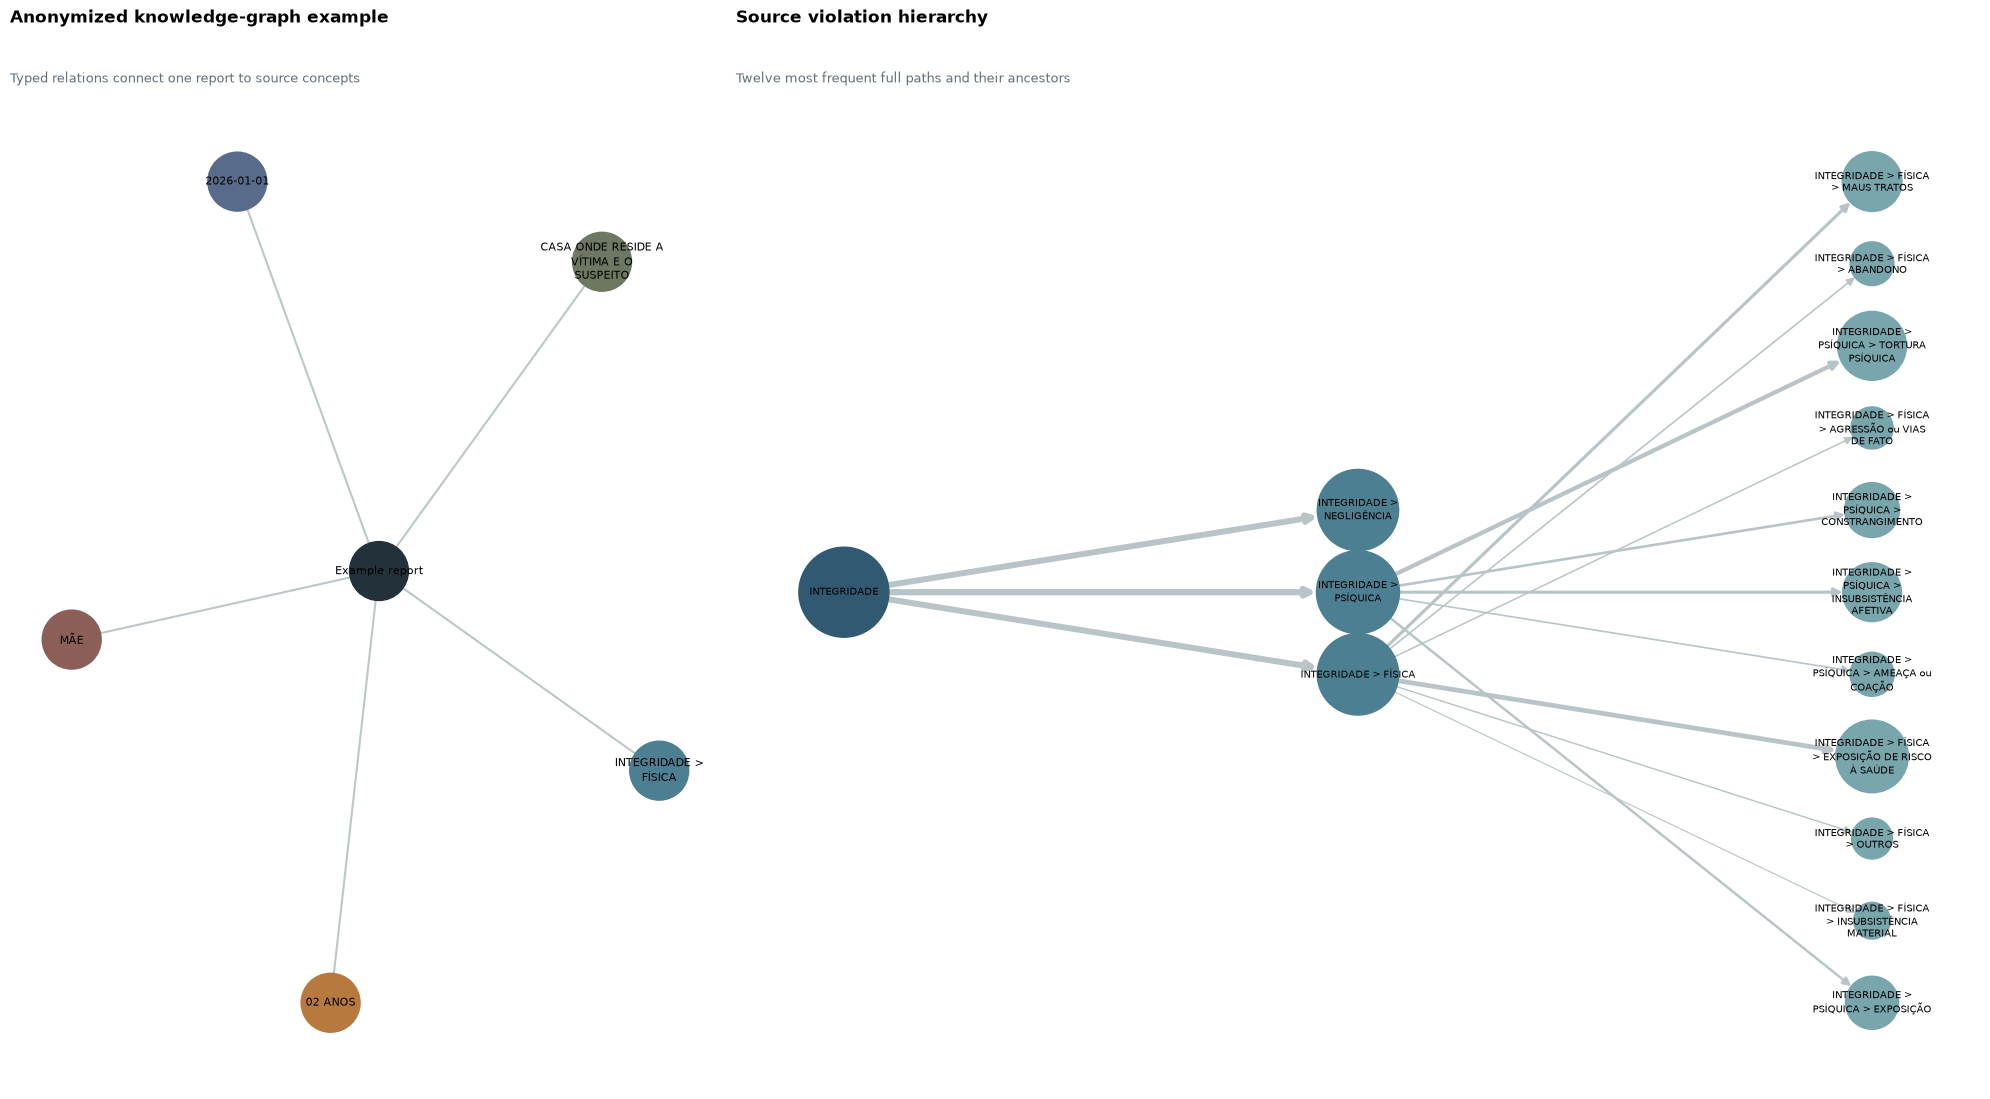

In [5]:
example_report = query_frame(CONFIG, 
    """
    WITH candidate AS (
        SELECT source_hash
        FROM public.disque100_reports
        WHERE registered_at >= %s
          AND registered_at < %s
          AND victim_gender = %s
        GROUP BY source_hash
        ORDER BY md5(source_hash || %s)
        LIMIT 1
    )
    SELECT DISTINCT
        date_trunc('month', registered_at)::date AS month,
        violation,
        victim_age_group,
        victim_suspect_relationship,
        violation_setting
    FROM public.disque100_reports
    JOIN candidate USING (source_hash)
    WHERE registered_at >= %s
      AND registered_at < %s
      AND victim_gender = %s
    """,
    (CONFIG.registered_from, CONFIG.registered_before, CONFIG.victim_gender, str(CONFIG.sample_seed), CONFIG.registered_from, CONFIG.registered_before, CONFIG.victim_gender),
)

knowledge_graph = nx.Graph()
example_report_node = "report:example"
knowledge_graph.add_node(
    example_report_node,
    node_type="report",
    display_label="Example report",
    report_count=1,
)
example_dimensions = [
    ("violation", "category", "has violation"),
    ("victim_age_group", "age_group", "has victim age"),
    ("victim_suspect_relationship", "relationship", "has relationship"),
    ("violation_setting", "setting", "occurred in"),
    ("month", "month", "registered during"),
]
for column, node_type, relation in example_dimensions:
    values = example_report[column].dropna().astype(str).drop_duplicates().head(3)
    for value in values:
        display_label = value if column != "violation" else category_from_violation(value)
        node_id = f"{node_type}:{display_label}"
        knowledge_graph.add_node(
            node_id,
            node_type=node_type,
            display_label=display_label,
            report_count=1,
        )
        knowledge_graph.add_edge(
            example_report_node, node_id, relation=relation, weight=1
        )

hierarchy_graph = nx.DiGraph()
support_lookup = {
    row.path: int(row.report_count) for row in hierarchy_support.itertuples()
}
for violation in top_full_violations:
    levels = split_violation(violation)
    prefixes = [" > ".join(levels[:index]) for index in range(1, len(levels) + 1)]
    for index, path in enumerate(prefixes, start=1):
        hierarchy_graph.add_node(
            path,
            node_type=["domain", "category", "subtype", "detail"][min(index - 1, 3)],
            level=index,
            report_count=int(support_lookup[path]),
        )
        if index > 1:
            hierarchy_graph.add_edge(
                prefixes[index - 2], path, relation="contains", weight=int(support_lookup[path])
            )

assert_positive_edge_weights(knowledge_graph)
assert_positive_edge_weights(hierarchy_graph)

figure, axes = plt.subplots(1, 2, figsize=(20, 11), gridspec_kw={"width_ratios": [0.8, 1.4]})

knowledge_positions = nx.spring_layout(knowledge_graph, seed=42, weight="weight")
knowledge_node_colors = [
    ENTITY_COLORS[knowledge_graph.nodes[node]["node_type"]] for node in knowledge_graph.nodes
]
nx.draw_networkx(
    knowledge_graph,
    pos=knowledge_positions,
    ax=axes[0],
    labels=wrapped_labels(knowledge_graph, 18),
    node_color=knowledge_node_colors,
    node_size=1800,
    edge_color="#BCC7CA",
    width=1.5,
    font_size=8,
)
axes[0].set_title(
    "Anonymized knowledge-graph example", loc="left", weight="bold", y=1.065
)
axes[0].text(
    0, 1.01, "Typed relations connect one report to source concepts",
    transform=axes[0].transAxes, color="#607078", fontsize=9, va="bottom",
)
axes[0].axis("off")

hierarchy_positions = nx.multipartite_layout(hierarchy_graph, subset_key="level", align="vertical")
hierarchy_counts = [hierarchy_graph.nodes[node]["report_count"] for node in hierarchy_graph.nodes]
hierarchy_node_colors = [
    ENTITY_COLORS[hierarchy_graph.nodes[node]["node_type"]] for node in hierarchy_graph.nodes
]
hierarchy_edge_widths = scale_values(
    [data["weight"] for _, _, data in hierarchy_graph.edges(data=True)], 0.8, 4.5
)
nx.draw_networkx(
    hierarchy_graph,
    pos=hierarchy_positions,
    ax=axes[1],
    labels=wrapped_labels(hierarchy_graph, 20),
    node_color=hierarchy_node_colors,
    node_size=scale_values(hierarchy_counts, 700, 4200),
    edge_color="#B8C4C7",
    width=hierarchy_edge_widths,
    arrows=True,
    arrowsize=12,
    font_size=7,
)
axes[1].set_title(
    "Source violation hierarchy", loc="left", weight="bold", y=1.065
)
axes[1].text(
    0, 1.01, "Twelve most frequent full paths and their ancestors",
    transform=axes[1].transAxes, color="#607078", fontsize=9, va="bottom",
)
axes[1].axis("off")

figure.patch.set_facecolor("white")
figure.tight_layout()
foundations_png = RESULTS_DIR / "semantic-foundations.png"
figure.savefig(foundations_png, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

nx.write_graphml(knowledge_graph, RESULTS_DIR / "knowledge-example.graphml")
nx.write_graphml(hierarchy_graph, RESULTS_DIR / "violation-hierarchy.graphml")

## 5. Build the category co-occurrence graph

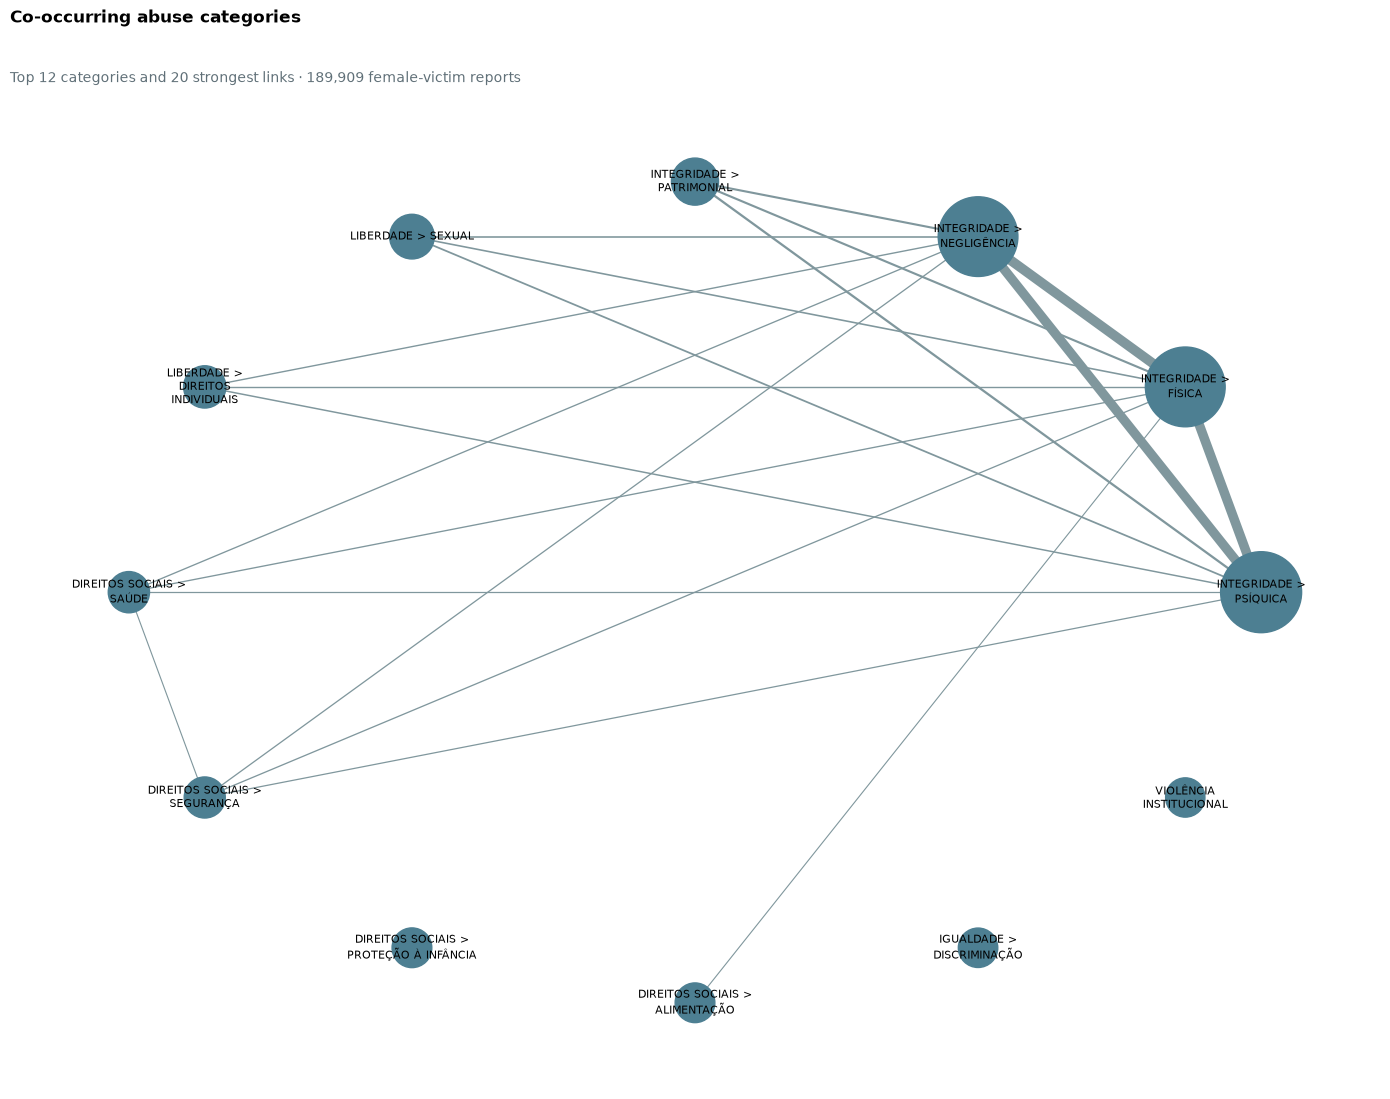

In [6]:
cooccurrence_edges = query_frame(CONFIG, 
    """
    WITH report_categories AS (
        SELECT DISTINCT
            source_hash,
            concat_ws(
                ' > ',
                nullif(trim(split_part(violation, '>', 1)), ''),
                nullif(trim(split_part(violation, '>', 2)), '')
            ) AS category
        FROM public.disque100_reports
        WHERE registered_at >= %s
          AND registered_at < %s
          AND victim_gender = %s
          AND violation IS NOT NULL
    )
    SELECT a.category AS source, b.category AS target, count(*) AS report_count
    FROM report_categories AS a
    JOIN report_categories AS b
      ON a.source_hash = b.source_hash
     AND a.category < b.category
    WHERE a.category = ANY(%s) AND b.category = ANY(%s)
    GROUP BY a.category, b.category
    ORDER BY report_count DESC, source, target
    LIMIT 20
    """,
    (CONFIG.registered_from, CONFIG.registered_before, CONFIG.victim_gender, top_categories, top_categories),
)

cooccurrence_graph = nx.Graph()
category_count_lookup = category_support.set_index("category")["report_count"].astype(int).to_dict()
for category in top_categories:
    cooccurrence_graph.add_node(
        category, node_type="category", report_count=category_count_lookup[category]
    )
for row in cooccurrence_edges.itertuples():
    cooccurrence_graph.add_edge(
        row.source, row.target, relation="co-occurs with", weight=int(row.report_count)
    )
assert_positive_edge_weights(cooccurrence_graph)

positions = nx.circular_layout(cooccurrence_graph)
figure, axis = plt.subplots(figsize=(14, 11))
node_counts = [cooccurrence_graph.nodes[node]["report_count"] for node in cooccurrence_graph.nodes]
edge_counts = [data["weight"] for _, _, data in cooccurrence_graph.edges(data=True)]
nx.draw_networkx(
    cooccurrence_graph,
    pos=positions,
    ax=axis,
    labels=wrapped_labels(cooccurrence_graph, 19),
    node_color=ENTITY_COLORS["category"],
    node_size=scale_values(node_counts, 800, 3400),
    edge_color="#80979D",
    width=scale_values(edge_counts, 0.8, 7),
    font_size=8,
)
axis.set_title(
    "Co-occurring abuse categories", loc="left", weight="bold", y=1.065
)
axis.text(
    0, 1.01,
    f"Top 12 categories and 20 strongest links · {female_report_count:,} female-victim reports",
    transform=axis.transAxes, color="#607078", fontsize=10, va="bottom",
)
axis.axis("off")
figure.patch.set_facecolor("white")
figure.tight_layout()
cooccurrence_png = RESULTS_DIR / "abuse-cooccurrence.png"
figure.savefig(cooccurrence_png, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

nx.write_graphml(cooccurrence_graph, RESULTS_DIR / "abuse-cooccurrence.graphml")

## 6. Build contextual bipartite graphs

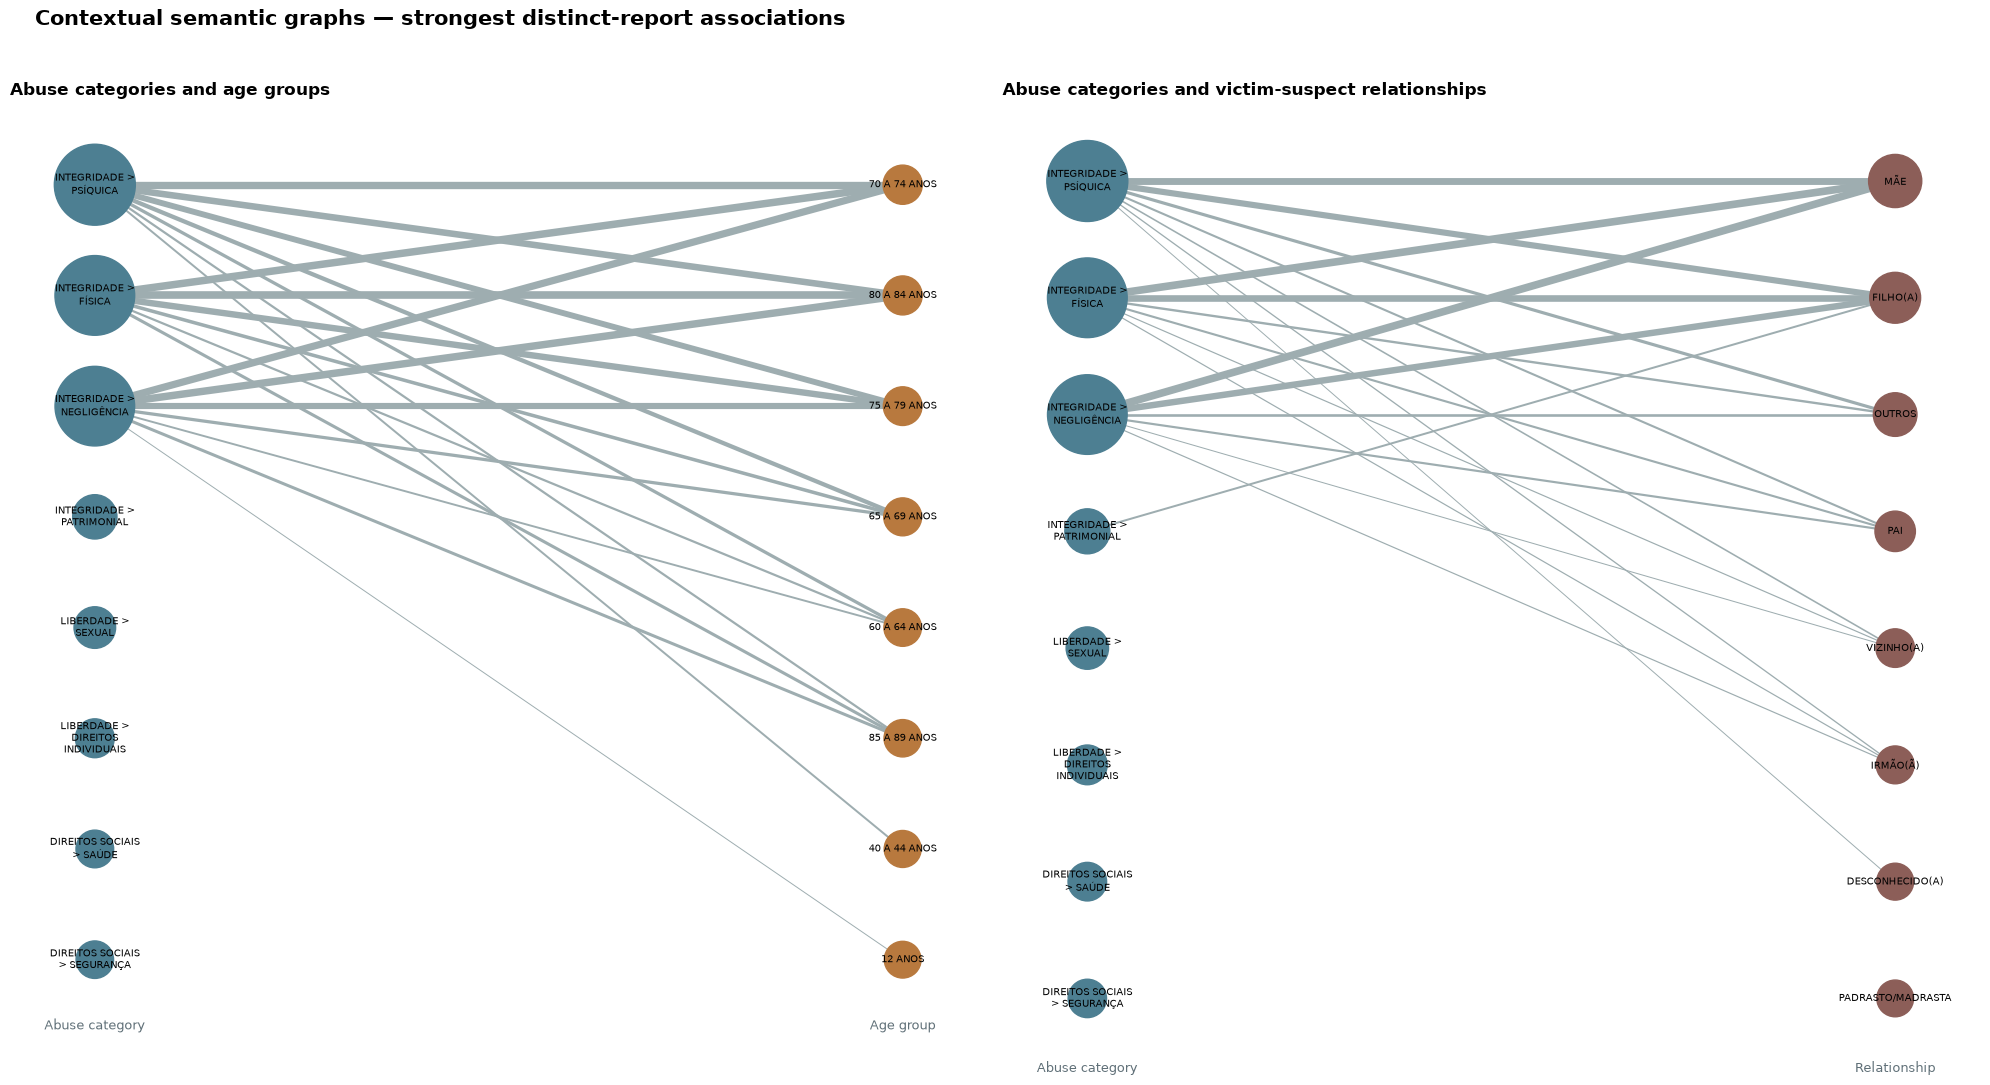

In [7]:
top_context_categories = top_categories[:8]
age_support = query_frame(CONFIG, 
    """
    SELECT victim_age_group AS value, count(DISTINCT source_hash) AS report_count
    FROM public.disque100_reports
    WHERE registered_at >= %s
      AND registered_at < %s
      AND victim_gender = %s
      AND victim_age_group IS NOT NULL
    GROUP BY victim_age_group
    ORDER BY report_count DESC, value
    LIMIT 8
    """,
    (CONFIG.registered_from, CONFIG.registered_before, CONFIG.victim_gender),
)
relationship_support = query_frame(CONFIG, 
    """
    SELECT victim_suspect_relationship AS value, count(DISTINCT source_hash) AS report_count
    FROM public.disque100_reports
    WHERE registered_at >= %s
      AND registered_at < %s
      AND victim_gender = %s
      AND victim_suspect_relationship IS NOT NULL
    GROUP BY victim_suspect_relationship
    ORDER BY report_count DESC, value
    LIMIT 8
    """,
    (CONFIG.registered_from, CONFIG.registered_before, CONFIG.victim_gender),
)


def context_edges(attribute_column, top_values):
    if attribute_column not in {"victim_age_group", "victim_suspect_relationship"}:
        raise ValueError("Unsupported context attribute")
    query = sql.SQL("""
    WITH report_categories AS (
        SELECT DISTINCT
            source_hash,
            concat_ws(
                ' > ',
                nullif(trim(split_part(violation, '>', 1)), ''),
                nullif(trim(split_part(violation, '>', 2)), '')
            ) AS category
        FROM public.disque100_reports
        WHERE registered_at >= %s
          AND registered_at < %s
          AND victim_gender = %s
          AND violation IS NOT NULL
    ), report_attributes AS (
        SELECT DISTINCT source_hash, {attribute} AS value
        FROM public.disque100_reports
        WHERE registered_at >= %s
          AND registered_at < %s
          AND victim_gender = %s
          AND {attribute} IS NOT NULL
    )
    SELECT categories.category, attributes.value, count(*) AS report_count
    FROM report_categories AS categories
    JOIN report_attributes AS attributes USING (source_hash)
    WHERE categories.category = ANY(%s) AND attributes.value = ANY(%s)
    GROUP BY categories.category, attributes.value
    ORDER BY report_count DESC, categories.category, attributes.value
    LIMIT 20
    """).format(attribute=sql.Identifier(attribute_column))
    return query_frame(CONFIG, 
        query,
        (
            CONFIG.registered_from, CONFIG.registered_before, CONFIG.victim_gender,
            CONFIG.registered_from, CONFIG.registered_before, CONFIG.victim_gender,
            top_context_categories, top_values,
        ),
    )


age_edges = context_edges("victim_age_group", age_support["value"].tolist())
relationship_edges = context_edges(
    "victim_suspect_relationship", relationship_support["value"].tolist()
)


def build_context_graph(edge_frame, support_frame, attribute_type):
    graph = nx.Graph()
    for category in top_context_categories:
        graph.add_node(
            category,
            node_type="category",
            report_count=category_count_lookup[category],
            partition=0,
        )
    attribute_counts = support_frame.set_index("value")["report_count"].astype(int).to_dict()
    for value, report_count in attribute_counts.items():
        graph.add_node(
            value,
            node_type=attribute_type,
            report_count=report_count,
            partition=1,
        )
    for row in edge_frame.itertuples():
        graph.add_edge(
            row.category,
            row.value,
            relation="co-occurs with",
            weight=int(row.report_count),
        )
    assert_positive_edge_weights(graph)
    return graph


age_graph = build_context_graph(age_edges, age_support, "age_group")
relationship_graph = build_context_graph(
    relationship_edges, relationship_support, "relationship"
)


def draw_bipartite_context(graph, axis, title, right_label):
    left_nodes = [node for node, data in graph.nodes(data=True) if data["partition"] == 0]
    right_nodes = [node for node, data in graph.nodes(data=True) if data["partition"] == 1]
    left_positions = np.linspace(1, -1, len(left_nodes))
    right_positions = np.linspace(1, -1, len(right_nodes))
    positions = {
        **{node: (0, y) for node, y in zip(left_nodes, left_positions)},
        **{node: (1, y) for node, y in zip(right_nodes, right_positions)},
    }
    node_colors = [ENTITY_COLORS[graph.nodes[node]["node_type"]] for node in graph.nodes]
    node_counts = [graph.nodes[node]["report_count"] for node in graph.nodes]
    edge_counts = [data["weight"] for _, _, data in graph.edges(data=True)]
    nx.draw_networkx(
        graph,
        pos=positions,
        ax=axis,
        labels=wrapped_labels(graph, 17),
        node_color=node_colors,
        node_size=scale_values(node_counts, 700, 3400),
        edge_color="#9EADB0",
        width=scale_values(edge_counts, 0.7, 5.5),
        font_size=7,
    )
    axis.set_title(title, loc="left", weight="bold")
    axis.text(0, -1.18, "Abuse category", ha="center", fontsize=9, color="#607078")
    axis.text(1, -1.18, right_label, ha="center", fontsize=9, color="#607078")
    axis.axis("off")


figure, axes = plt.subplots(1, 2, figsize=(20, 11))
draw_bipartite_context(age_graph, axes[0], "Abuse categories and age groups", "Age group")
draw_bipartite_context(
    relationship_graph,
    axes[1],
    "Abuse categories and victim-suspect relationships",
    "Relationship",
)
figure.suptitle(
    "Contextual semantic graphs — strongest distinct-report associations",
    x=0.02, ha="left", fontsize=15, weight="bold",
)
figure.patch.set_facecolor("white")
figure.tight_layout(rect=[0, 0, 1, 0.96])
context_png = RESULTS_DIR / "abuse-context.png"
figure.savefig(context_png, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

nx.write_graphml(age_graph, RESULTS_DIR / "age-context.graphml")
nx.write_graphml(relationship_graph, RESULTS_DIR / "relationship-context.graphml")

## 7. Validate privacy-safe outputs

In [8]:
expected_png_files = {
    RESULTS_DIR / "semantic-foundations.png",
    RESULTS_DIR / "abuse-cooccurrence.png",
    RESULTS_DIR / "abuse-context.png",
}
expected_graphml_files = {
    RESULTS_DIR / "knowledge-example.graphml",
    RESULTS_DIR / "violation-hierarchy.graphml",
    RESULTS_DIR / "abuse-cooccurrence.graphml",
    RESULTS_DIR / "age-context.graphml",
    RESULTS_DIR / "relationship-context.graphml",
}
for artifact in expected_png_files | expected_graphml_files | {
    CLUSTER_PROFILES_FILE,
    CATEGORY_SUPPORT_FILE,
}:
    require_artifact(artifact, "02_semantic_abuse_graphs.ipynb")
    assert_public_artifact_safe(artifact)

for graph in (
    knowledge_graph,
    hierarchy_graph,
    cooccurrence_graph,
    age_graph,
    relationship_graph,
):
    assert_positive_edge_weights(graph)

write_manifest(
    PATHS,
    CONFIG,
    {
        "female_report_count": female_report_count,
        "female_month_count": female_month_count,
        "cluster_profiles": len(cluster_profiles),
        "static_png_files": len(expected_png_files),
        "static_graphml_files": len(expected_graphml_files),
    },
)

print("Static semantic analysis checks passed.")
print(f"Female-victim reports: {female_report_count:,}")
print(f"Observed cluster profiles: {len(cluster_profiles):,}")
print(f"Static PNG figures: {len(expected_png_files)}")
print(f"Static GraphML artifacts: {len(expected_graphml_files)}")


Static semantic analysis checks passed.
Female-victim reports: 189,909
Observed cluster profiles: 30
Static PNG figures: 3
Static GraphML artifacts: 5


## Takeaways

- The knowledge graph makes typed source relations explicit without exposing a report identifier.
- The hierarchy preserves the source taxonomy; it does not introduce an external legal classification.
- Co-occurrence and bipartite edges represent distinct-report associations, not causation or prevalence.
- Cluster profiles are descriptive bridges from structural similarity to source semantics.